# Featurization Model selection

In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.utils import resample
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
%matplotlib inline

# Q1 Import libraries and read the dataset.

In [2]:
# Reading the csv file.
flat_df = pd.read_csv("kc_house_data.csv")
flat_df.head(10)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
5,7237550310,20140512T000000,1230000.0,4,4.50,5420,101930,1.0,0,0,...,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930
6,1321400060,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
7,2008000270,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711
8,2414600126,20150415T000000,229500.0,3,1.00,1780,7470,1.0,0,0,...,7,1050,730,1960,0,98146,47.5123,-122.337,1780,8113
9,3793500160,20150312T000000,323000.0,3,2.50,1890,6560,2.0,0,0,...,7,1890,0,2003,0,98038,47.3684,-122.031,2390,7570


# Q2 Explore Data Analysis. Find out how one variable related to other and distributions of data.

In [3]:
flat_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
id               21613 non-null int64
date             21613 non-null object
price            21613 non-null float64
bedrooms         21613 non-null int64
bathrooms        21613 non-null float64
sqft_living      21613 non-null int64
sqft_lot         21613 non-null int64
floors           21613 non-null float64
waterfront       21613 non-null int64
view             21613 non-null int64
condition        21613 non-null int64
grade            21613 non-null int64
sqft_above       21613 non-null int64
sqft_basement    21613 non-null int64
yr_built         21613 non-null int64
yr_renovated     21613 non-null int64
zipcode          21613 non-null int64
lat              21613 non-null float64
long             21613 non-null float64
sqft_living15    21613 non-null int64
sqft_lot15       21613 non-null int64
dtypes: float64(5), int64(15), object(1)
memory usage: 3.5+ MB


In [4]:
# splitting data into training and test set for independent attributes
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [5]:
# drop the columns id, date, zipcode
flat_df = flat_df.drop(['id','date','zipcode'],axis=1)


C:\Users\user\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


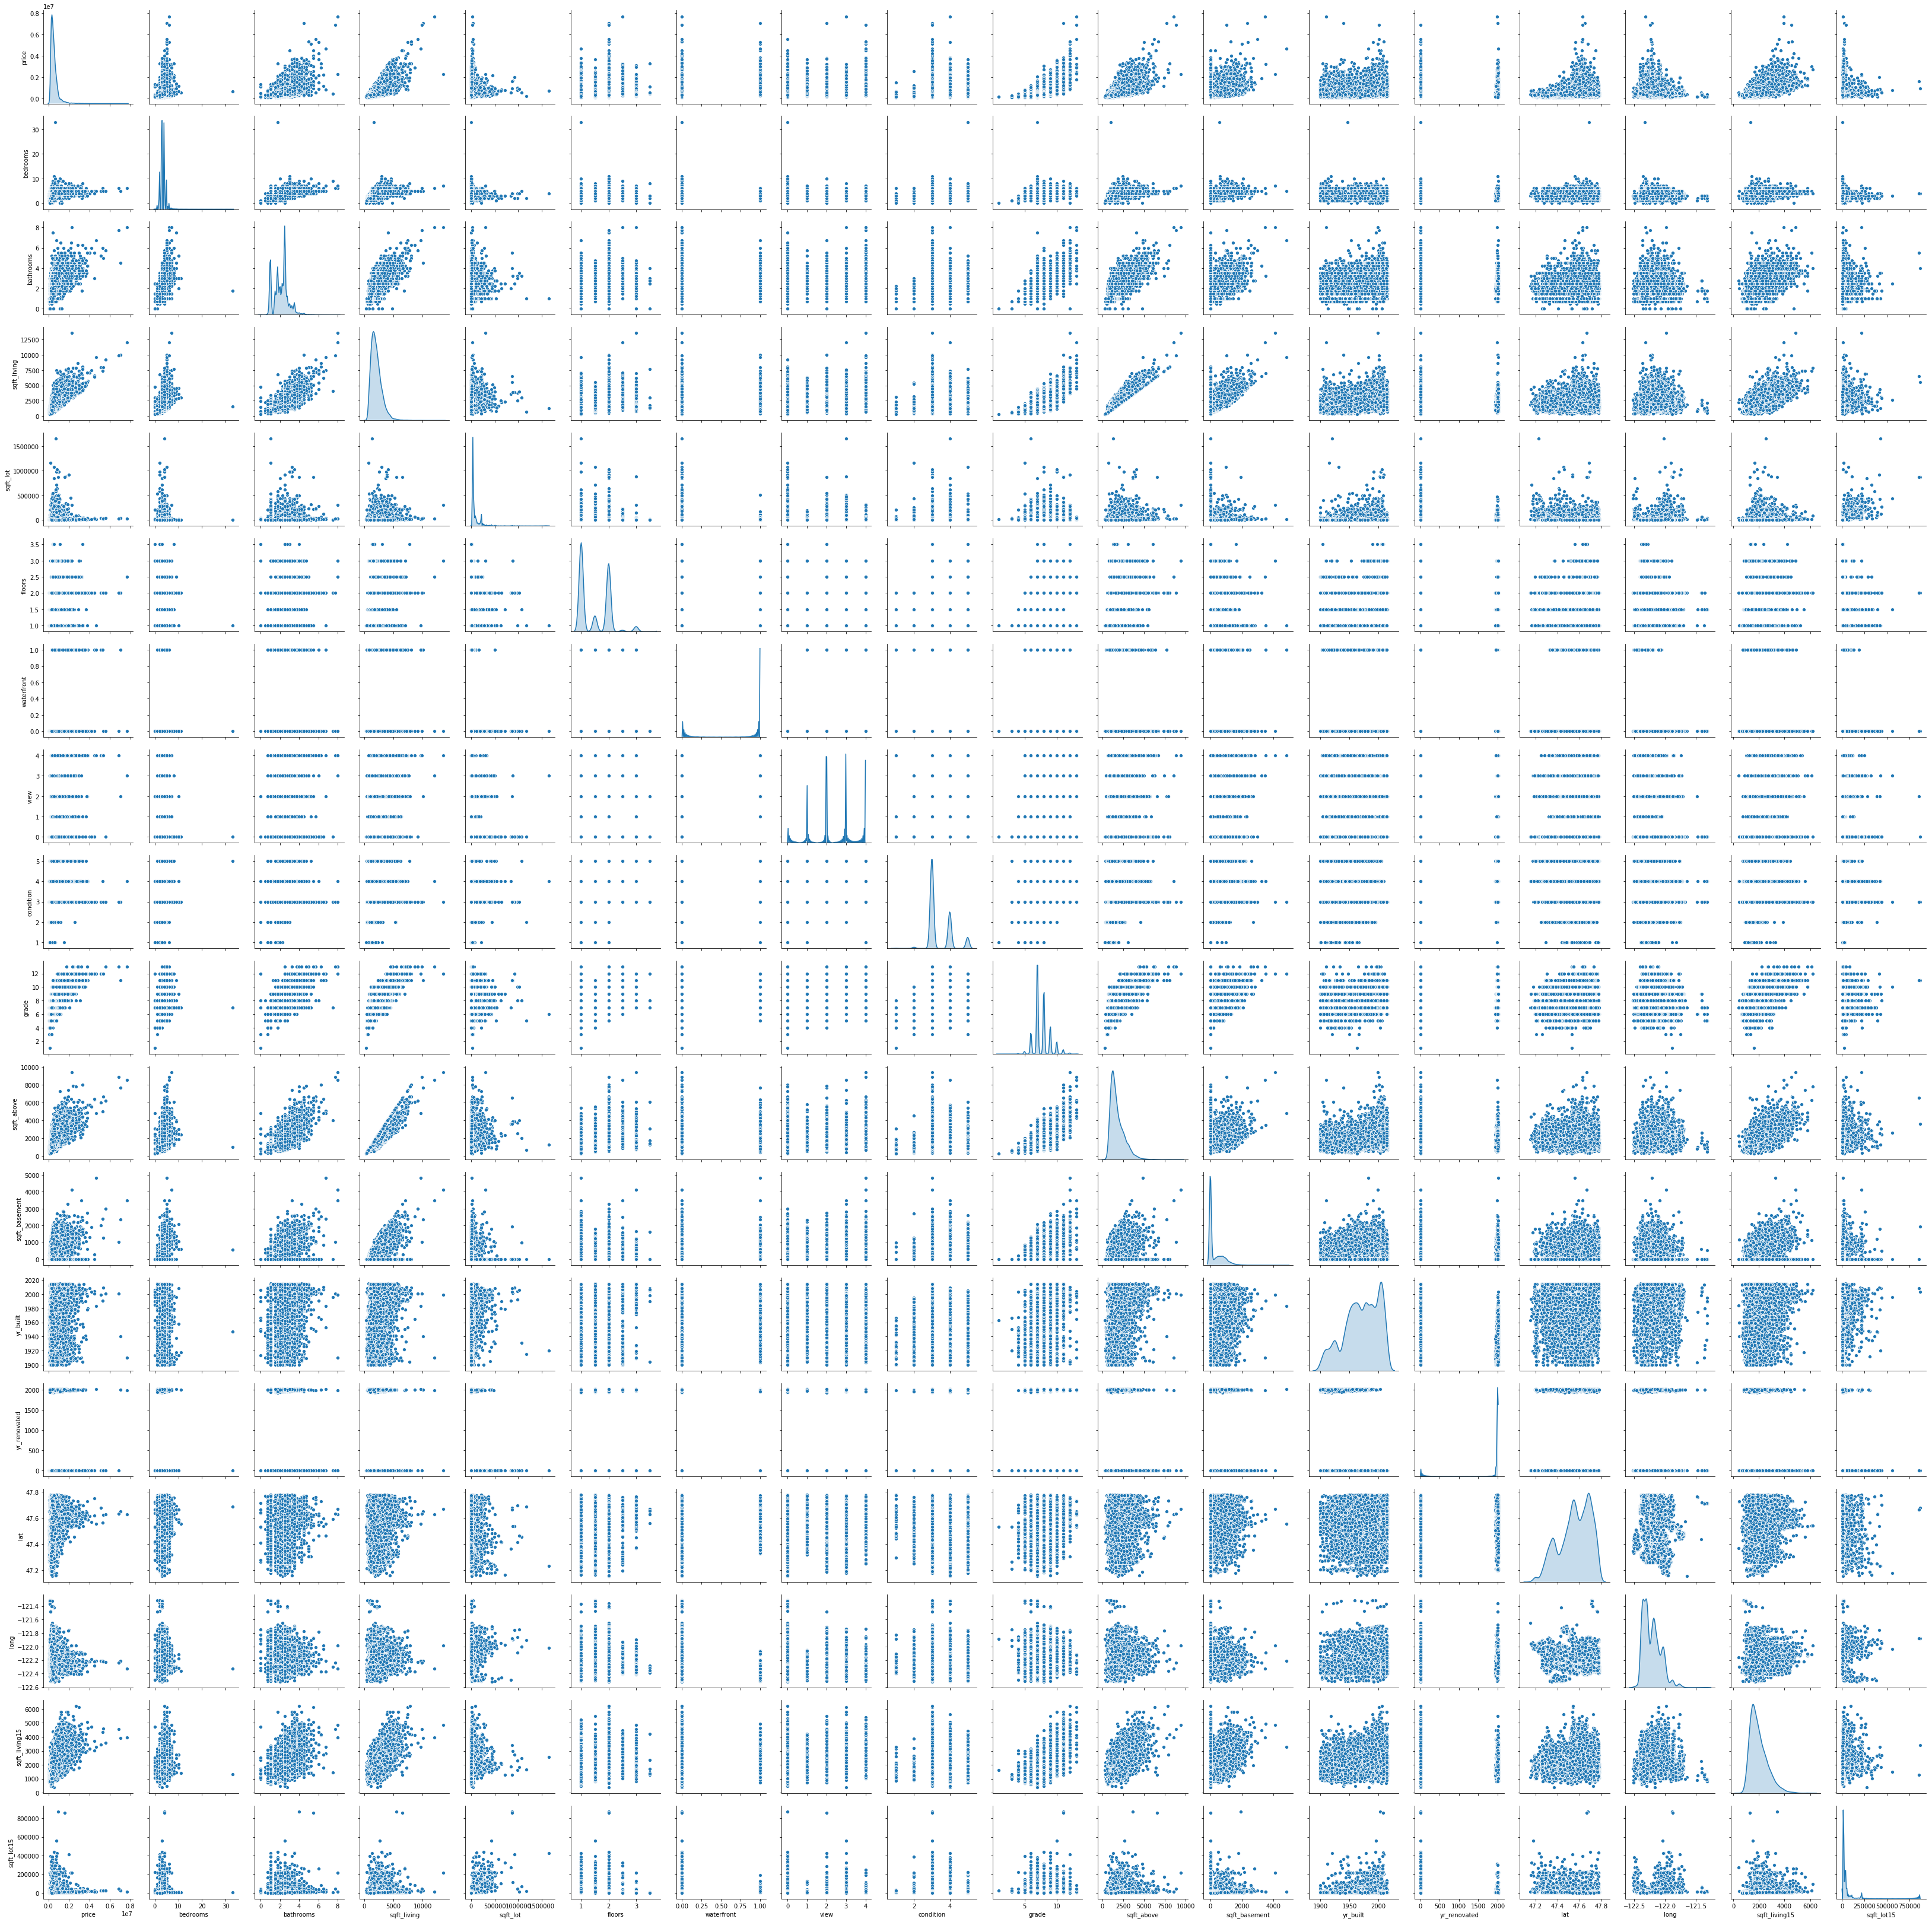

In [6]:
#see the disctibution
import seaborn as sns
sns.pairplot(flat_df,diag_kind='kde')

In [7]:
# find the correlation between the independent variable(prices) to the other variables
cor = flat_df.corr()
cor_target = abs(cor["price"])

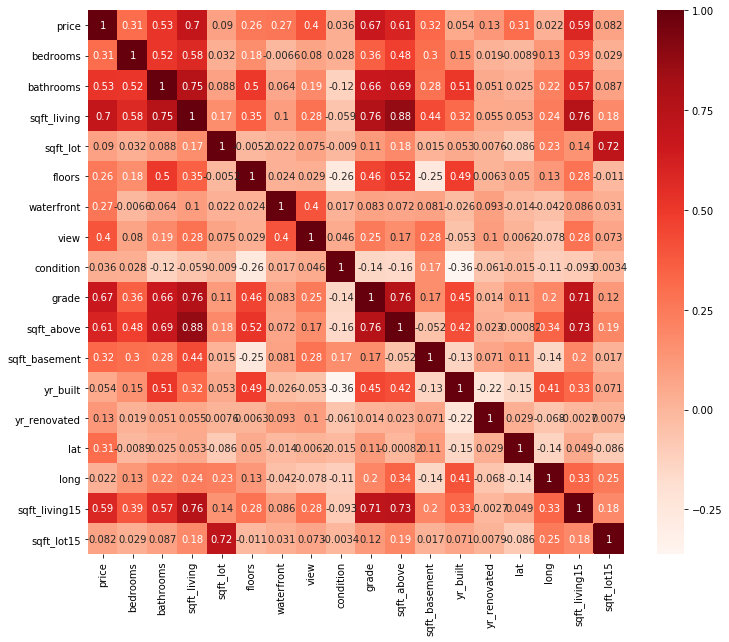

In [8]:
plt.figure(figsize=(12,10))
sns.heatmap(cor, annot=True, cmap=plt.cm.Reds)
plt.show()

# Q3 State your insights.

### The diagonal of the above matirx shows the auto-correlation of the variables. It is always 1. We can observe that the correlation between price and grade is highest i.e. 0.67 and then between price and sqft_above i.e. 0.61. Also it indicates that most important fetaures are bedrooms, bathrooms, sqft_living, grade and yr_built to estimate the house price. 

# Q4. Build a linear regression model to predict the house prices

In [14]:
#Selecting highly correlated features
relevant_features = cor_target[cor_target>0.3]
relevant_features 

price            1.000000
bedrooms         0.308338
bathrooms        0.525134
sqft_living      0.702044
view             0.397346
grade            0.667463
sqft_above       0.605566
sqft_basement    0.323837
lat              0.306919
sqft_living15    0.585374
Name: price, dtype: float64

In [15]:
X =  flat_df[["bedrooms","bathrooms","sqft_living","view","grade","sqft_above","sqft_basement","lat","sqft_living15"]]
y =  flat_df[["price"]]
y= y.rename(columns={'price':'Class'})
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.30, random_state=1)


In [16]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(Xtrain,ytrain)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None,
         normalize=False)

In [17]:
y_pred=model.predict(Xtest)
rmse=np.sqrt(np.mean((ytest-y_pred)**2))
rmse

Class    239239.488948
dtype: float64

In [18]:
model.score(Xtest,ytest)

0.6336695474749785

# Q5: Remove any unwanted columns or outliers, standardize variables in this pre-processing step

### The 'id','date' and 'zipcode' columns are already removed in the above step 8, since they are not adding any value for our house price prediction.


# Q6 Use appropriate cross validations techniques to find out the best predictor parameters and best prediction.

In [19]:
#2. Considering all the features
X =  flat_df.drop(["price"],axis=1)
y['Class'] =  flat_df[["price"]]
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.30, random_state=1)
model.fit(Xtrain,ytrain)
y_pred=model.predict(Xtest)
rmse=np.sqrt(np.mean((ytest-y_pred)**2))
rmse

Class    221500.839014
dtype: float64

In [20]:
model.score(Xtest,ytest)

0.6859794704654314

In [21]:
from sklearn.preprocessing import PolynomialFeatures

In [22]:
#3. decisiontree classifier Model
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(criterion = 'entropy' )
dt_model.fit(Xtrain, ytrain)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=None,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=None,
            splitter='best')

In [23]:
y_predict=dt_model.predict(Xtest)

In [24]:
cr=metrics.classification_report(ytest,y_predict)
print(cr)

              precision    recall  f1-score   support

     82000.0       0.00      0.00      0.00         0
     82500.0       0.00      0.00      0.00         1
     83000.0       0.00      0.00      0.00         1
     84000.0       0.00      0.00      0.00         0
     86500.0       0.00      0.00      0.00         1
     90000.0       0.00      0.00      0.00         1
     95000.0       0.00      0.00      0.00         0
     96500.0       0.00      0.00      0.00         1
     99000.0       0.00      0.00      0.00         0
    100000.0       0.00      0.00      0.00         1
    104950.0       0.00      0.00      0.00         1
    105000.0       0.00      0.00      0.00         1
    107000.0       0.00      0.00      0.00         1
    109000.0       0.00      0.00      0.00         0
    109500.0       0.00      0.00      0.00         1
    110000.0       0.00      0.00      0.00         2
    114000.0       0.00      0.00      0.00         1
    114975.0       0.00    

C:\Users\user\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\user\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1145: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples.
  'recall', 'true', average, warn_for)
C:\Users\user\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
C:\Users\user\Anaconda3\lib\site-packages\sklearn\metrics\classification.py:1145: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples.
  'recall', 'true', average, warn_for)
C:\Users\user\Anaconda3\lib\site-pac

In [25]:
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X)

C:\Users\user\Anaconda3\lib\site-packages\sklearn\preprocessing\data.py:625: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
C:\Users\user\Anaconda3\lib\site-packages\sklearn\base.py:462: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  return self.fit(X, **fit_params).transform(X)


In [26]:
X_std.shape

(21613, 17)

In [27]:
cov_matrix = np.cov(X_std.T)

In [28]:
cov_matrix.shape

(17, 17)

C:\Users\user\Anaconda3\lib\site-packages\matplotlib\tight_layout.py:211: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations
  warnings.warn('Tight layout not applied. '


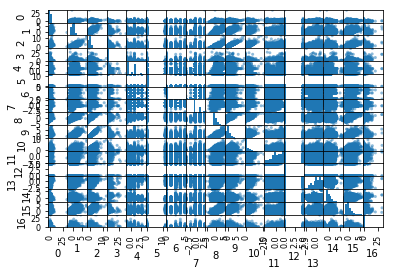

In [29]:
X_std_df = pd.DataFrame(X_std)
axes = pd.plotting.scatter_matrix(X_std_df)
plt.tight_layout()

In [30]:
eig_vals, eig_vecs = np.linalg.eig(cov_matrix)

In [31]:
eig_vals.shape

(17,)

In [32]:
eig_vecs.shape

(17, 17)

In [ ]:
print('Eigen Vectors \n%s', eig_vecs)
print('\n Eigen Values \n%s', eig_vals)


Eigen Vectors 
%s [[-2.51152224e-01 -1.70720869e-01  7.60214651e-02 -3.36960591e-01
  -5.49985541e-02  2.54565262e-01  1.24900516e-02  1.42908947e-01
  -4.88161954e-01 -4.36779017e-01  3.73137047e-01  6.80166656e-02
  -2.48764487e-01  7.84443278e-02 -7.30667758e-02  2.31811128e-01
   3.49696603e-16]
 [-3.71462288e-01 -4.00069772e-02  1.17690922e-01 -6.32251618e-02
  -4.87207066e-03  8.04501283e-02  9.82111321e-02  1.69148597e-01
  -1.49021780e-01  3.00227283e-01  1.42955067e-02  4.76557757e-01
  -2.39055527e-02 -4.17719170e-01  1.27583249e-01 -5.16546383e-01
  -7.19015224e-16]
 [-4.03837539e-01 -1.83858774e-01  5.07981867e-03 -1.10398056e-01
   2.13791525e-02  3.11828431e-02  4.99671224e-04 -5.43879935e-03
   5.90716751e-02 -7.12251561e-02 -1.47411516e-01 -3.90360546e-01
   2.19985637e-01  1.43738576e-01  6.87119023e-02 -2.09817894e-01
   6.99260367e-01]
 [-1.01760726e-01  5.81309142e-02 -6.28494392e-01  2.21812927e-02
   1.89437816e-01 -8.25969106e-02  6.63683917e-02  2.23718861e-01
 

In [33]:

eigen_pairs = [(np.abs(eig_vals[i]), eig_vecs[ :, i]) for i in range(len(eig_vals))]

In [ ]:
tot = sum(eig_vals)
var_exp = [( i /tot ) * 100 for i in sorted(eig_vals, reverse=True)]
cum_var_exp = np.cumsum(var_exp)
print("Cumulative Variance Explained", cum_var_exp)

Cumulative Variance Explained [ 30.11014739  42.22382775  52.82357462  60.48214931  66.90151089
  72.63914524  77.60902194  82.17797508  86.03661072  89.51879544
  92.45186061  94.3727342   96.05126007  97.54836749  98.87806224
 100.         100.        ]


In [ ]:
eigenvalues = eig_vals
eigenvectors = eig_vecs
eig_pairs = [(eigenvalues[index], eigenvectors[:,index]) for index in range(len(eigenvalues))]

# Sort the (eigenvalue, eigenvector) pairs from highest to lowest with respect to eigenvalue
eig_pairs.sort()

eig_pairs.reverse()
print(eig_pairs)

# Extract the descending ordered eigenvalues and eigenvectors
eigvalues_sorted = [eig_pairs[index][0] for index in range(len(eigenvalues))]
eigvectors_sorted = [eig_pairs[index][1] for index in range(len(eigenvalues))]

P_reduce = np.array(eigvectors_sorted[0:4])   # Reducing from 8 to 4 dimension space

X_std_4D = np.dot(X,P_reduce.T)   # projecting original data into principal component dimensions

Proj_data_df = pd.DataFrame(X_std_4D)  #


[(5.118961902850286, array([-0.25115222, -0.37146229, -0.40383754, -0.10176073, -0.24318502,
       -0.05054262, -0.12265596,  0.08863443, -0.37578415, -0.39838831,
       -0.09263774, -0.24793946, -0.00606021, -0.00823513, -0.17235741,
       -0.35975196, -0.10811328])), (2.059420947552971, array([-0.17072087, -0.04000698, -0.18385877,  0.05813091,  0.2720177 ,
       -0.23402192, -0.36809809, -0.3086895 , -0.03466808,  0.06557708,
       -0.50424716,  0.39072491, -0.19034857, -0.15827646,  0.29759353,
       -0.08096368,  0.06075232])), (1.8020403453547513, array([ 0.07602147,  0.11769092,  0.00507982, -0.62849439,  0.23216401,
       -0.05508961, -0.07514957, -0.12360475,  0.08664639,  0.0170217 ,
       -0.02130712,  0.0959113 , -0.00761593,  0.18444402, -0.23240465,
       -0.02894162, -0.63332499])), (1.3020179399886653, array([-0.33696059, -0.06322516, -0.11039806,  0.02218129,  0.22788867,
        0.59380325,  0.44575023, -0.31598439,  0.04471841,  0.01386753,
       -0.2550475

In [ ]:
tot = sum(eig_vals)
var_explained = [(i / tot) for i in sorted(eig_vals, reverse=True)]  # an array of variance explained by each 
# eigen vector... there will be 8 entries as there are 8 eigen vectors)
cum_var_exp = np.cumsum(var_explained)  # an array of cumulative variance. There will be 8 entries with 8 th entry 
# cumulative reaching almost 100
cum_var_exp

array([0.30110147, 0.42223828, 0.52823575, 0.60482149, 0.66901511,
       0.72639145, 0.77609022, 0.82177975, 0.86036611, 0.89518795,
       0.92451861, 0.94372734, 0.9605126 , 0.97548367, 0.98878062,
       1.        , 1.        ])

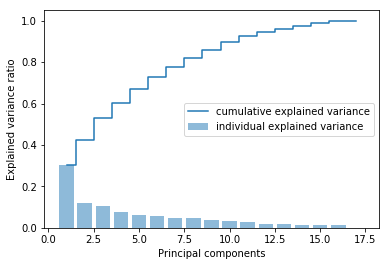

In [ ]:

import matplotlib.pyplot as plt 
plt.bar(range(1,18), var_explained, alpha=0.5, align='center', label='individual explained variance')
plt.step(range(1,18),cum_var_exp, where= 'mid', label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc = 'best')
plt.show()

In [ ]:
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.30, random_state=1)
xtrain

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15
2060,3,2.00,1540,6250,1.0,0,0,3,7,1540,0,1998,0,47.3539,-122.025,2070,6250
11759,2,1.00,810,7158,1.0,0,0,5,6,810,0,1944,0,47.4882,-122.325,1090,7158
8274,3,1.00,860,10426,1.0,0,0,3,6,860,0,1954,0,47.4987,-122.341,1140,11250
21272,4,2.50,1750,4779,2.0,0,0,3,7,1750,0,2009,0,47.7608,-122.232,1580,4687
14328,3,1.00,1410,9656,1.0,0,0,3,7,960,450,1953,0,47.6354,-122.208,2410,9384
3271,4,2.50,4600,67369,2.0,0,0,3,10,4600,0,1990,0,47.6417,-121.992,4600,67369
5302,5,2.75,2530,7601,1.0,0,0,3,7,1520,1010,1992,0,47.4683,-122.263,2400,7776
20457,3,2.50,2700,6947,2.0,0,3,3,9,2700,0,2013,0,47.5172,-122.208,2500,6947
4499,3,3.25,1370,1194,3.0,0,0,3,8,1370,0,2004,0,47.6718,-122.388,1800,2678
17990,3,1.00,860,1664,1.5,0,0,3,7,860,0,1927,0,47.6761,-122.384,1540,4080


In [ ]:
dt_model2 = DecisionTreeClassifier(criterion = 'entropy' )
dt_model2.fit(xtrain, ytrain)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=None,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=None,
            splitter='best')

In [ ]:
y_predict2=dt_model2.predict(xtest)

In [ ]:
acc2=metrics.accuracy_score(ytest,y_predict2)
acc2

0.010641579272054287

In [ ]:
import matplotlib.pyplot as plt
from sklearn import model_selection
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [ ]:
models = []
models.append(('LR', LogisticRegression()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
#models.append(('SVM', SVC()))
# evaluate each model in turn
results = []
names = []
scoring = 'accuracy'
for name, model in models:
	kfold = model_selection.KFold(n_splits=10, random_state=12345)
	cv_results = model_selection.cross_val_score(model, X_std, y, cv=kfold, scoring=scoring)
	results.append(cv_results)
	names.append(name)
	msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
	print(msg)
# boxplot algorithm comparison
fig = plt.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

C:\Users\user\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
C:\Users\user\Anaconda3\lib\site-packages\sklearn\utils\validation.py:761: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\user\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
C:\Users\user\Anaconda3\lib\site-packages\sklearn\linear_model\logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
C:\Users\user\Anaconda3\lib\site-packages\sklearn\utils\validation.py:761: DataConvers

In [ ]:
models = []
models.append(('LR', LogisticRegression()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
#models.append(('SVM', SVC()))
# evaluate each model in turn
results = []
names = []
scoring = 'accuracy'
for name, model in models:
	kfold = model_selection.KFold(n_splits=10, random_state=12345)
	cv_results = model_selection.cross_val_score(model, Proj_data_df, y, cv=kfold, scoring=scoring)
	results.append(cv_results)
	names.append(name)
	msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
	print(msg)
# boxplot algorithm comparison
fig = plt.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

In [ ]:

LR=LogisticRegression()
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn import linear_model, decomposition

In [ ]:
#Declare data preprocessing steps
pca = decomposition.PCA()
pipe = Pipeline(steps=[('pca', pca), ('logistic', LR)])

pca.fit(X) 


In [ ]:
n_components = [8,10,12]
estimator = GridSearchCV(pipe,dict(pca__n_components=n_components))
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
estimator.fit(X,y)

In [ ]:
estimator.best_params_

In [ ]:
estimator.best_score_